In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import recall_score, f1_score, confusion_matrix, precision_score

df = pd.read_csv("../data/processed_research_data.csv")

le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

features = [
    'step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
    'oldbalanceDest', 'newbalanceDest', 
    'orig_in_degree', 'orig_out_degree', 'orig_pagerank', 'orig_clustering',
    'dest_in_degree', 'dest_out_degree', 'dest_pagerank', 'orig_flow_ratio'
]

X = df[features].values
y = df["isFraud"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=2048, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=2048)

In [2]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.999, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

In [3]:
class HybridFraudModel(nn.Module):
    def __init__(self, input_size):
        super(HybridFraudModel, self).__init__()
        self.lstm = nn.LSTM(input_size, 128, num_layers=2, batch_first=True, dropout=0.2)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        return self.classifier(last_step)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridFraudModel(len(features)).to(device)
criterion = FocalLoss(alpha=0.999, gamma=2)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=2)

In [6]:
epochs = 10 
print(f"Starting Research Model Training on {device}...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss/len(train_loader)
    scheduler.step(avg_loss) 
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']}")

Starting Research Model Training on cpu...
Epoch 1/10 | Loss: 0.017548 | LR: 0.001
Epoch 2/10 | Loss: 0.004651 | LR: 0.001
Epoch 3/10 | Loss: 0.003822 | LR: 0.001
Epoch 4/10 | Loss: 0.003307 | LR: 0.001
Epoch 5/10 | Loss: 0.002989 | LR: 0.001
Epoch 6/10 | Loss: 0.002743 | LR: 0.001
Epoch 7/10 | Loss: 0.002618 | LR: 0.001
Epoch 8/10 | Loss: 0.002455 | LR: 0.001
Epoch 9/10 | Loss: 0.002430 | LR: 0.001
Epoch 10/10 | Loss: 0.002354 | LR: 0.001


In [7]:
model.eval()
preds = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        probs = torch.sigmoid(outputs) 
        preds.extend(probs.cpu().numpy())

y_pred = (np.array(preds) > 0.5).astype(int)

print("\n --- Final Research Model Evaluation ---")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


 --- Final Research Model Evaluation ---
Precision: 0.7653
Recall (Sensitivity): 0.7322
F1-Score: 0.7484

Confusion Matrix:
[[253807    369]
 [   440   1203]]


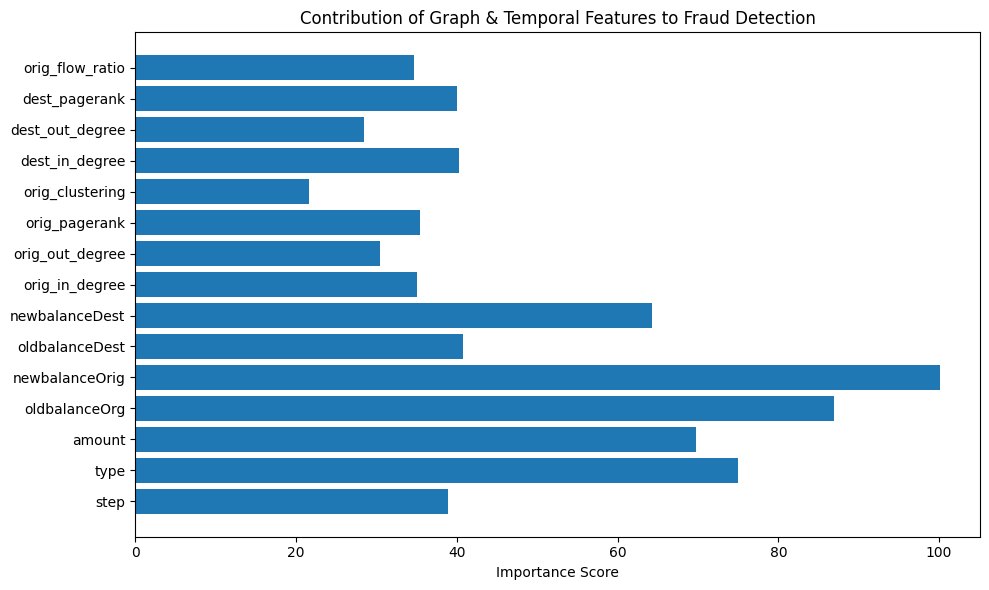

In [8]:
importances = np.abs(model.lstm.weight_ih_l0.cpu().detach().numpy()).sum(axis=0)
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title("Contribution of Graph & Temporal Features to Fraud Detection")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Calculating SHAP values... this might take 2-3 minutes.


  0%|          | 0/50 [00:00<?, ?it/s]

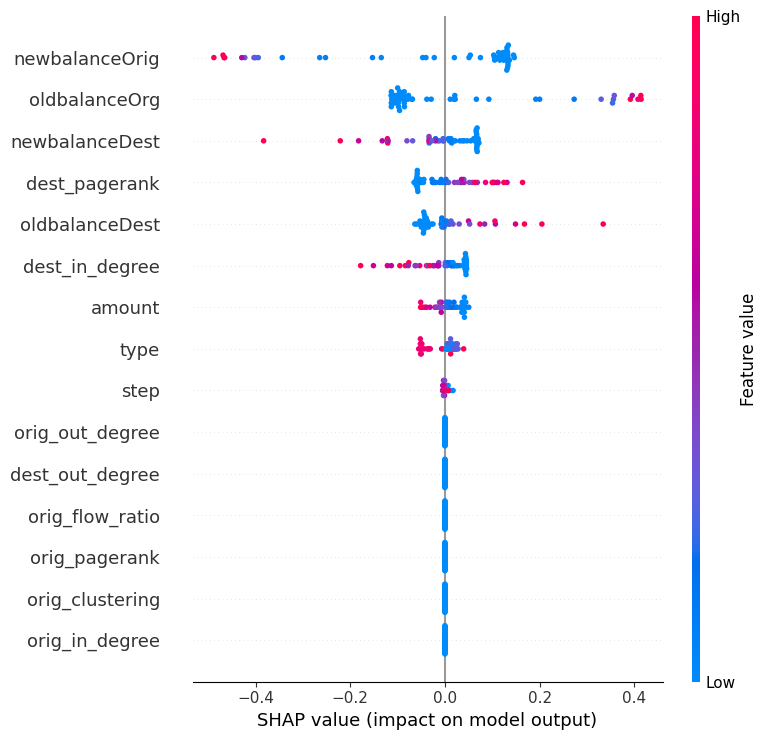

In [9]:
import shap 
import matplotlib.pyplot as plt

test_sample = X_test[:50] 

def predict_fn(x_np):
    x_tensor = torch.tensor(x_np, dtype=torch.float32).to(device)
    if len(x_tensor.shape) == 2:
        x_tensor = x_tensor.unsqueeze(1)
    
    model.eval()
    with torch.no_grad():
        outputs = model(x_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()
    return probs.flatten() 

background = X_train[:50] 
explainer = shap.KernelExplainer(predict_fn, background)

print("Calculating SHAP values... this might take 2-3 minutes.")
shap_values = explainer.shap_values(test_sample)

if isinstance(shap_values, list):
    display_shap = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    display_shap = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(display_shap, test_sample, feature_names=features)
plt.show()

In [10]:
import torch
import os

if not os.path.exists("../models"):
    os.makedirs("../models")

model_save_path = "../models/hybrid_research_model.pth"
torch.save(model.state_dict(), model_save_path)

print(f" Model saved as: {model_save_path}")

 Model saved as: ../models/hybrid_research_model.pth


Threshold Optimization Table:
   Threshold  Precision    Recall        F1
0        0.1   0.114428  0.991479  0.205177
1        0.2   0.439606  0.897139  0.590072
2        0.3   0.594739  0.811929  0.686567
3        0.4   0.683980  0.761412  0.720622
4        0.5   0.765267  0.732197  0.748367
5        0.6   0.851111  0.699330  0.767792
6        0.7   0.929302  0.664029  0.774583
7        0.8   0.991063  0.607425  0.753208
8        0.9   1.000000  0.483871  0.652174


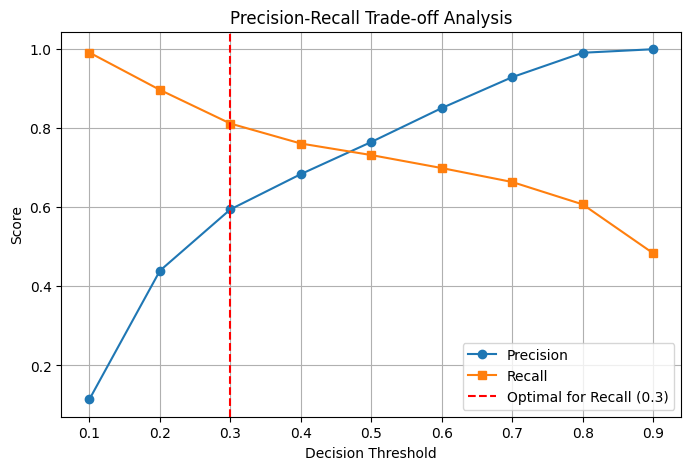

In [11]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for t in thresholds:
    y_pred_t = (np.array(preds) > t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    results.append({'Threshold': t, 'Precision': p, 'Recall': r, 'F1': f1})

df_thresholds = pd.DataFrame(results)
print("Threshold Optimization Table:")
print(df_thresholds)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(df_thresholds['Threshold'], df_thresholds['Precision'], label='Precision', marker='o')
plt.plot(df_thresholds['Threshold'], df_thresholds['Recall'], label='Recall', marker='s')
plt.axvline(x=0.3, color='red', linestyle='--', label='Optimal for Recall (0.3)')
plt.title("Precision-Recall Trade-off Analysis")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_recalls = []

print("Running 5-Fold Cross Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    pass



Running 5-Fold Cross Validation...
